In [3]:
import pandas as pd
df = pd.read_csv('ecommerce_sales_34500.csv')
print(df.head(10))

  order_id customer_id product_id     category   price  discount  quantity  \
0  O100000      C17270    P234890         Home  164.08      0.15         1   
1  O100001      C17603    P228204      Grocery   24.73      0.00         1   
2  O100002      C10860    P213892  Electronics  175.58      0.05         1   
3  O100003      C15390    P208689  Electronics   63.67      0.00         1   
4  O100004      C15226    P228063         Home   16.33      0.15         1   
5  O100005      C15191    P214062       Beauty   53.91      0.10         2   
6  O100006      C13772    P201363  Electronics  266.50      0.00         1   
7  O100007      C13092    P216691       Beauty    9.98      0.00         1   
8  O100008      C15734    P202751      Fashion    6.61      0.05         1   
9  O100009      C16265    P207782      Grocery   10.91      0.00         1   

  payment_method  order_date  delivery_time_days region returned  \
0    Credit Card  2023-12-23                   4   West       No   
1    

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  str    
 1   customer_id         34500 non-null  str    
 2   product_id          34500 non-null  str    
 3   category            34500 non-null  str    
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  str    
 8   order_date          34500 non-null  str    
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  str    
 11  returned            34500 non-null  str    
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  int64  
 16  customer_gender

In [5]:
df.shape

(34500, 17)

In [6]:
df.isna().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
print(df["category"].unique())
print(df["payment_method"].unique())
print(df["region"].unique())
print(df["returned"].unique())

<StringArray>
['Home', 'Grocery', 'Electronics', 'Beauty', 'Fashion', 'Toys', 'Sports']
Length: 7, dtype: str
<StringArray>
['Credit Card', 'UPI', 'COD', 'PayPal', 'Debit Card', 'Wallet']
Length: 6, dtype: str
<StringArray>
['West', 'South', 'North', 'East', 'Central']
Length: 5, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [9]:
df.describe()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


In [10]:
df["discount"].value_counts().sort_index()

discount
0.00    18939
0.05     6176
0.10     4159
0.15     2795
0.20     1727
0.30      704
Name: count, dtype: int64

In [11]:
df["order_date"] = pd.to_datetime(df["order_date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   order_id            34500 non-null  str           
 1   customer_id         34500 non-null  str           
 2   product_id          34500 non-null  str           
 3   category            34500 non-null  str           
 4   price               34500 non-null  float64       
 5   discount            34500 non-null  float64       
 6   quantity            34500 non-null  int64         
 7   payment_method      34500 non-null  str           
 8   order_date          34500 non-null  datetime64[us]
 9   delivery_time_days  34500 non-null  int64         
 10  region              34500 non-null  str           
 11  returned            34500 non-null  str           
 12  total_amount        34500 non-null  float64       
 13  shipping_cost       34500 non-null  float64       
 14  p

In [12]:
df.to_csv('ecommerce_sales_cleaned.csv',index=False)

In [13]:
# How many orders belong to each category?
df["category"].value_counts()

category
Fashion        6254
Electronics    6180
Home           5487
Toys           4247
Sports         4171
Beauty         4103
Grocery        4058
Name: count, dtype: int64

In [14]:
# Whats the most common payment method?
df["payment_method"].value_counts()

payment_method
Credit Card    12170
Debit Card      8505
COD             4160
UPI             4156
PayPal          3444
Wallet          2065
Name: count, dtype: int64

In [15]:
# Revenue by category
df.groupby("category")["total_amount"].sum().sort_values(ascending=False)

category
Electronics    3319206.50
Home           1077681.52
Sports          629825.54
Fashion         471545.80
Beauty          153019.38
Toys            132013.80
Grocery          82000.51
Name: total_amount, dtype: float64

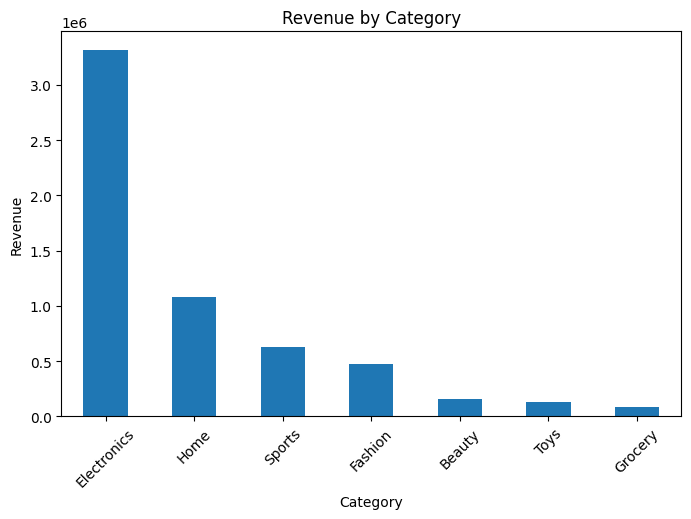

In [16]:
# Visulaization of the revenue by category
import matplotlib.pyplot as plt

revenue_by_category = (
    df.groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category.plot(kind="bar", figsize=(8, 5))

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()
